В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
cars_df = pd.read_csv('cars.csv')

In [3]:
cars_df.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [4]:
cars_df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [5]:
cars_df['Fuel_Type'].unique()

array(['Petrol', 'Diesel'], dtype=object)

In [6]:
cars_df['Owner_Type'].unique()

array(['First', 'Second', 'Third'], dtype=object)

In [7]:
cars_df['Seats'].unique()

array([5, 4, 7])

In [8]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


В наборі даних 8 числових (включаючи колонку `Car_ID`) і 5 категоріальних колонок з них:
* 2 бінарні (`Transmission`, `Fuel_Type`)
* 2 мультикатегоріальні 
* 1 мультикатегоріальнi з порядком (`Owner_Typeґ)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [9]:
inputs = cars_df.drop(columns = 'Price')

In [10]:
targets = cars_df['Price']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size = 0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [12]:
cars_df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64

In [13]:
is_petrol = {'Diesel' : 0, 'Petrol' : 1}
X_train['is_petrol'] = X_train.Fuel_Type.map(is_petrol)
X_test['is_petrol'] = X_test.Fuel_Type.map(is_petrol)

In [14]:
cars_df['Transmission'].value_counts()

Transmission
Automatic    57
Manual       43
Name: count, dtype: int64

In [15]:
is_automatic = {'Manual' : 0, 'Automatic' : 1}
X_train['is_automatic'] = X_train.Transmission.map(is_automatic)
X_test['is_automatic'] = X_test.Transmission.map(is_automatic)

In [16]:
from sklearn.preprocessing import OneHotEncoder

ehc = OneHotEncoder()
ehc.fit(X_train[['Brand']])

brand_cols = ehc.categories_[0]
X_train[brand_cols] = ehc.transform(X_train[['Brand']]).toarray()
X_test[brand_cols] = ehc.transform(X_test[['Brand']]).toarray()

In [17]:
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [18]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [19]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,is_petrol,is_automatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,is_petrol,is_automatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [20]:
num_cols = X_train.select_dtypes(exclude = 'object')
num_cols_with_y = pd.concat([num_cols, y_train], axis=1)

In [21]:
corr = num_cols.corr()
corr.style.background_gradient()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,is_petrol,is_automatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849
is_petrol,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122
is_automatic,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886
Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925


In [22]:
corr[(corr.abs() > 0.5) & (corr != 1)].stack()

Year               Kilometers_Driven   -0.708525
Kilometers_Driven  Year                -0.708525
Mileage            Engine              -0.710516
                   Power               -0.684705
Engine             Mileage             -0.710516
                   Power                0.801638
Power              Mileage             -0.684705
                   Engine               0.801638
                   is_automatic         0.586910
is_automatic       Power                0.586910
dtype: float64

Високу кореляцію показують пари змінних:
* `Year` i `Kilometers_Driven`
* `Mileage` i `Engine`
* `Power` i `Mileage`
* `Engine` i `Power`
* `Power` i `Power`


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [23]:
X_train = X_train.select_dtypes(exclude = 'object')
X_test = X_test.select_dtypes(exclude = 'object')

model = LinearRegression()
model.fit(X_train, y_train)
prediction_x_train = model.predict(X_train)
prediction_x_test = model.predict(X_test)


In [24]:
loss_train = np.sqrt(mean_squared_error(y_train, prediction_x_train, ))
loss_test =  np.sqrt(mean_squared_error(y_test, prediction_x_test, ))
display(loss_train, loss_test)

np.float64(210293.5782815185)

np.float64(258181.5611203283)

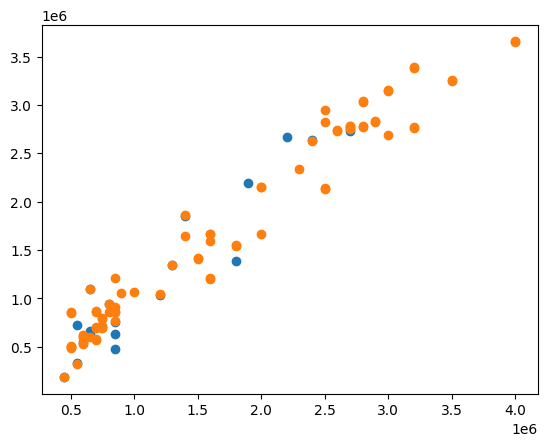

In [25]:
plt.scatter(y_test, prediction_x_test, label = 'Графік розсіювання для тестового набору')
plt.scatter(y_train, prediction_x_train, label = 'Графік розсіювання для тренувального набору')

Висновки:
* В принципі модель непогана, модель вловила тренд
* Тренувальних (помаранчевих) точок більше, модель не зламаламь
* Але немає суцільнох лінії, що обгрунтовує метрику RMSE

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [26]:
scaler = StandardScaler()
scaler = scaler.fit(X_train)

scaled_inputs = scaler.transform(X_train)
scaled_inputs_test = scaler.transform(X_test)

scaler.var_, scaler.mean_

(array([7.99036094e+02, 1.25609375e+00, 8.40810938e+07, 1.16335937e+01,
        4.31270294e+05, 6.62974984e+03, 5.49375000e-01, 2.49843750e-01,
        2.37343750e-01, 9.00000000e-02, 9.98437500e-02, 9.98437500e-02,
        5.85937500e-02, 6.93750000e-02, 4.75000000e-02, 5.85937500e-02,
        9.98437500e-02, 1.09375000e-01, 9.00000000e-02, 7.98437500e-02,
        4.27500000e-01]),
 array([5.3162500e+01, 2.0183625e+03, 2.8362500e+04, 1.7062500e+01,
        1.9107375e+03, 1.6688750e+02, 5.2250000e+00, 5.1250000e-01,
        6.1250000e-01, 1.0000000e-01, 1.1250000e-01, 1.1250000e-01,
        6.2500000e-02, 7.5000000e-02, 5.0000000e-02, 6.2500000e-02,
        1.1250000e-01, 1.2500000e-01, 1.0000000e-01, 8.7500000e-02,
        6.5000000e-01]))

In [27]:
model_scaled = LinearRegression()
model_scaled = model_scaled.fit(scaled_inputs, y_train)
weight_df = pd.DataFrame({
    'feature': np.append(X_train.columns, 1),
    'weight': np.append(model_scaled.coef_, model_scaled.intercept_)
})



In [28]:
weight_df.sort_values(by='weight', ascending = False)

,feature,weight
21,1,1.680000e+06
5,Power,4.967692e+05
16,Mercedes,2.100488e+05
10,BMW,2.084073e+05
9,Audi,2.056001e+05
8,is_automatic,1.166938e+05
20,Owner_Type_Codes,4.234495e+04
18,Toyota,1.580570e+04
0,Car_ID,5.608685e+03
6,Seats,-2.148925e+03


Висновки:
* В принципі все логічно: найвпливовіша змінна `Power`, далі за нею преміальні марки машин `Mercedes`, `BMW`, `Audi`
* Найбільний негативний показник, тобто він впливаж наскільки зменшиться вартість автомобіля це `is_petrol` та бюджетні марки машин `Hyundai`, `Mahindra` і тд

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [29]:
cols = ['const'] + X_train.columns.tolist()

In [31]:
scaled_inputs = pd.DataFrame(scaled_inputs, columns=X_train.columns, index = X_train.index)
X_train_ols = sm.add_constant(scaled_inputs)
model_OLS = sm.OLS(y_train, X_train_ols)
results = model_OLS.fit()


In [32]:
print(results.summary().tables[1].as_text())

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.74e+04     61.363      0.000    1.63e+06    1.73e+06
Car_ID             5608.6854   3.37e+04      0.166      0.869   -6.19e+04    7.31e+04
Year              -8765.6457   6.09e+04     -0.144      0.886   -1.31e+05    1.13e+05
Kilometers_Driven  -9.44e+04   6.51e+04     -1.449      0.153   -2.25e+05    3.59e+04
Mileage           -1.317e+05   5.83e+04     -2.259      0.028   -2.48e+05    -1.5e+04
Engine            -2.138e+04   7.29e+04     -0.293      0.770   -1.67e+05    1.24e+05
Power              4.968e+05   7.54e+04      6.588      0.000    3.46e+05    6.48e+05
Seats             -2148.9245   4.22e+04     -0.051      0.960   -8.66e+04    8.23e+04
is_petrol         -1.838e+05   4.57e+04     -4.026      0.000   -2.75e+05   -9.25e+04
is_automatic       1.167e+05    4.4e+04      2.653    

In [33]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           2.01e-33
Time:                        17:35:52   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.74e+0

Стат. значущі змінні: 
* `Const`
* `Mileage`
* `Power`
* `is_petrol`
* `is_automatic	`
* `Audi`
* `BMW`
* `Ford`
* `Hyundai`
* `Mahindra`
* `Maruti`
* `Mercedes`
* `Volkswagen`

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [34]:
scaled_inputs_train_df = pd.DataFrame(scaled_inputs, columns=X_train.columns)

In [35]:
important_features = scaled_inputs_train_df[['Mileage', 'Power', 'is_petrol', 'is_automatic','Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen' ]]

In [36]:
important_features = sm.add_constant(important_features)
model_important_features = sm.OLS(y_train, important_features)
results = model_important_features.fit()
print(results.summary().tables[1].as_text())
print(results.summary().tables[0].as_text())

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          1.68e+06   2.78e+04     60.360      0.000    1.62e+06    1.74e+06
Mileage       -1.43e+05   4.02e+04     -3.561      0.001   -2.23e+05   -6.29e+04
Power         4.556e+05    5.1e+04      8.941      0.000    3.54e+05    5.57e+05
is_petrol    -1.337e+05   2.99e+04     -4.479      0.000   -1.93e+05   -7.41e+04
is_automatic  1.311e+05    4.3e+04      3.046      0.003    4.52e+04    2.17e+05
Audi          2.497e+05   3.53e+04      7.075      0.000    1.79e+05     3.2e+05
BMW            2.95e+05   3.78e+04      7.802      0.000     2.2e+05     3.7e+05
Ford         -4.855e+04   3.52e+04     -1.378      0.173   -1.19e+05    2.18e+04
Hyundai      -1.027e+05   3.17e+04     -3.238      0.002   -1.66e+05   -3.94e+04
Mahindra     -8.538e+04   3.02e+04     -2.825      0.006   -1.46e+05    -2.5e+04
Maruti       -5.118e+04   3.

Показники R2 та Adj. R-squared змінились мінімально, на  ~0.005, тобто ми можемо використовувати суто стат значущі ознаки

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

p_value < 0.25 :
* `Mileage`
* `Power`
* `is_petrol`
* `is_automatic	`
* `Audi`
* `BMW`
* `Ford`
* `Hyundai`
* `Mahindra`
* `Maruti`
* `Mercedes`
* `Volkswagen`
* `Kilometers_Driven`
* `Тата`


In [39]:
features_under_p0_25 = pd.DataFrame(scaled_inputs[['Mileage', 'Power', 'is_petrol', 'is_automatic','Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen', 'Kilometers_Driven', 'Tata' ]])

In [45]:
features_under_p0_25 = sm.add_constant(features_under_p0_25)
p_0_25_model = sm.OLS(y_train, features_under_p0_25)
results = p_0_25_model.fit()
print(results.summary().tables[0].as_text())
print(results.summary().tables[1].as_text())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     98.58
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           3.84e-38
Time:                        17:47:37   Log-Likelihood:                -1097.4
No. Observations:                  80   AIC:                             2225.
Df Residuals:                      65   BIC:                             2260.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.72e+0

Ми порівняли три моделі, і найкращою виявилася остання, де використовувався поріг P-value менше 0.25. Вона показала найвищі результати: R-квадрат склав 0.955, а скоригований R-квадрат — 0.945. Оскільки в попередніх моделях ці показники були дещо нижчими (0.951 та 0.943 відповідно), я вважаю за доцільне використовувати саме цей фінальний варіант